# Tandem bike

Two students must reach the exam in time. Tandem together: fast, time to review (3, 3). Bikes separately: in time, no review (1, 1). One alone on the tandem arrives late (0), the other arrives in time and improves their rank (2).

In [ ]:
#if nashpy is not installed on colab, install it with
#!pip install nashpy

In [ ]:
# !!!! ONLY ON COLAB !!!!
# To use the jupyter books and myNashTools.py on Google Colab, 
#  you need to give access to your personal Google Drive
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')

# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/GameMatrix" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/GameMatrix'  # Change this to the path where you put the jupyter books and myNashTools.py
if my_folder not in sys.path: 
    sys.path.insert(0, my_folder)
if os.path.exists(my_folder):
    print(f"OK! the folder exists ! So you can use the jupyter books and myNashTools.py in this folder.")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)    
    # Force insertion of the folder at the beginning of the path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)        
else:
    print(f"ERROR: folder does not exist at this path. Verify the spelling or the space.")


In [ ]:
#For all : Colab or your local computer :
import numpy as np, nashpy as nash, matplotlib.pyplot as plt
from myNashTools import print_equilibria, plot_indifference

---
## Exercise

Two students "A" and "B" are on the beach, they have to take a bike to be in time at the university for the exam.  

They can use both a tandem to go faster and have time to remove sand and review the course.  
Or a bike separately, but they will not have time to review..  
If one take a bike and the other a tandem; the student with the tandem alone will not reach the university in time; and the other is sure to increase his, her rank. 

Here is the matrix

| **A** \  B  | tandem | bike |
|---|---|---|
| **tandem** | (**3**, 3) | (**0**, 2) |
| **bike** | (**2**, 0) | (**1**, 1) |

In [ ]:
# In nashpy:
acts = ['tandem', 'bike']
A = np.array([[3, 0], [2, 1]])
game = nash.Game(A, A.T)   # B is  symmetric of A

**Q1.** Find the Nash equilibria in pure strategies.

> **Solution.**   
> if A chooses Tandem, insterest's B if to choose tandem; and A has interest to stay on tandem  
> if A chooses Bike, insterest's B if to choose Bike; and A has interest to stay on Bike  
> Symetric for B, 2 pure Nash equilibria :  **(tandem, tandem)** and **(bike, bike)**.  
> OR another explanation
> for A : best cells in each column = (0,0), (1,1)   
> for B : best cells in each row = (0,0), (1,1)  
> $bestCellsA \cap bestCellsB = \lbrace (0,0), (1,1)\rbrace $ 

**Q2.** Find the mixed-strategy equilibrium.

> **Solution.** 
> let $p$ = Probability A take a tandem  
> $E(B|B=tandem) = 3.p + 0.(1-p) = 3.p$  
> $E(B|B=bike) = 2.p + (1-p) = 2-p$   
> indifference when $3.p = 2-p \equiv p = 2/4 = 1/2$  $\Rightarrow$ equilibrium for A $(1/2, 1/2)$   
> by symmetry,  equilibrium for B $(1/2, 1/2)$  
> payoff :   
> | **A** \  B  | tandem p(1/2) | bike p(1/2)|  
> |---|---|---|  
> | **tandem** p(1/2)| p(1/4) | p(1/4) |  
> | **bike** p(1/2)| p(1/4) | p(1/4) |  
> 
> $payoff(A) = 1/4\times 3 + 1/4\times 0 + 1/4\times 2+ 1/4 = 3/4+2/4+1/4 = 6/4 = 3/2$  
> $payoff(B) = 3/2$ (symmetry)


*Check with nashpy*

Equilibrium 1:  A -> [tandem: 1]   B -> [tandem: 1]   payoffs = (3, 3)
Equilibrium 2:  A -> [bike: 1]   B -> [bike: 1]   payoffs = (1, 1)
Equilibrium 3:  A -> [tandem: 1/2, bike: 1/2]   B -> [tandem: 1/2, bike: 1/2]   payoffs = (3/2, 3/2)


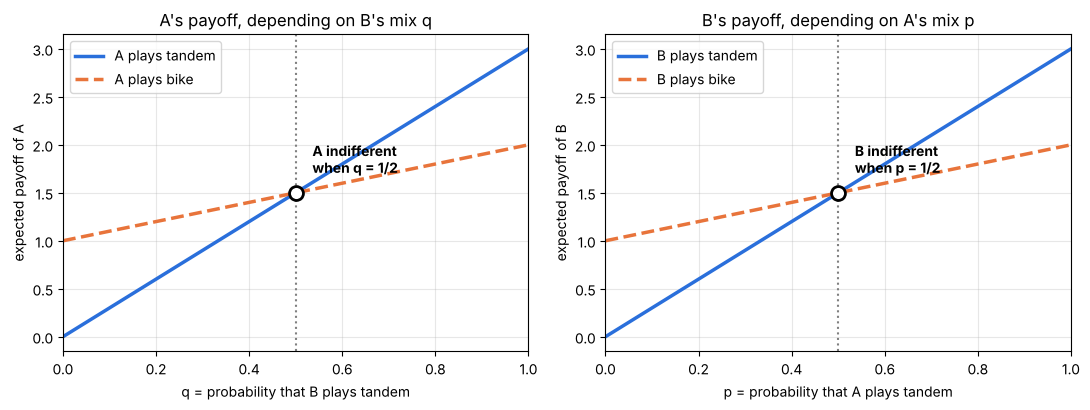

In [ ]:
print_equilibria(game, acts, acts)


In [ ]:
plot_indifference(game, acts, acts); plt.show()

**How to read the diagram.**

- **Left:** A's expected payoff for each of its two actions, depending on $q$ (how often B plays *tandem*).
  Where the line of an action is higher, A prefers that action. Where the two lines cross, A is **indifferent**.
- **Right:** the same for B, depending on $p$ (how often A plays *tandem*).

In the mixed equilibrium, each player chooses the probability that puts the **other** player exactly on the crossing point:
B plays $q$ = the crossing value of the left panel, A plays $p$ = the crossing value of the right panel.

**Q3.** What do you conclude?

> **Solution.**   
> (tandem, tandem) is better for **both**, but risky: the bike guarantees 1.  
> The tandem pays only if the other takes it with probability ≥ 1/2.  
> Talking beforehand is enough and credible: nobody has an interest in lying.